Import Libraries

In [7]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error

from geopy.distance import geodesic

Load Dataset

In [4]:
df = pd.read_csv('data/combined_final_dataset.csv')

print(df.shape)
df.head()

(4503, 23)


,ListingID,City,Locality,PropertyType,BHK,Bathrooms,Balconies,Furnishing,SuperBuiltUpArea_sqft,BuiltUpArea_sqft,...,Parking,BuildingType,YearBuilt,AgeYears,Facing,AmenitiesCount,IsRERARegistered,Latitude,Longitude,Price_INR
0,HP01630,Kolkata,Rajarhat,Apartment,1,2.0,1.0,Unfurnished,1098,870,...,Basement,Mid Rise,2010.0,15,North-West,9,True,22.584035,88.440364,7130000
1,HP01608,Kolkata,Salt Lake,Apartment,1,2.0,3.0,Unfurnished,863,710,...,Open,High Rise,2006.0,19,South,6,True,22.535687,88.416707,5920000
2,HP01399,Hyderabad,Madhapur,Apartment,3,4.0,1.0,Semi-Furnished,2662,2176,...,Open,Standalone Building,2010.0,15,North,6,True,17.444963,78.431430,20300000
3,HP00219,Ahmedabad,Thaltej,Apartment,2,3.0,2.0,Semi-Furnished,1814,1533,...,Covered,High Rise,2004.0,21,South-West,7,True,23.063364,72.593854,9230000
4,HP02088,Bengaluru,Electronic City,Row House,3,4.0,2.0,Furnished,1722,1298,...,Covered,Bungalow,2014.0,11,South,7,True,12.948053,77.785061,14890000


Basic Cleaning

In [6]:
# drop unnecessary columns
df.drop(['ListingID', 'Locality'], axis=1, inplace=True, errors='ignore')

# drop nulls in important columns
df.dropna(subset=['Latitude', 'Longitude', 'CarpetArea_sqft'], inplace=True)

# fill remaining nulls
df.ffill(inplace=True)

,City,PropertyType,BHK,Bathrooms,Balconies,Furnishing,SuperBuiltUpArea_sqft,BuiltUpArea_sqft,CarpetArea_sqft,Floor,...,Parking,BuildingType,YearBuilt,AgeYears,Facing,AmenitiesCount,IsRERARegistered,Latitude,Longitude,Price_INR
0,Kolkata,Apartment,1,2.0,1.0,Unfurnished,1098,870,771,4,...,Basement,Mid Rise,2010.0,15,North-West,9,True,22.584035,88.440364,7130000
1,Kolkata,Apartment,1,2.0,3.0,Unfurnished,863,710,611,3,...,Open,High Rise,2006.0,19,South,6,True,22.535687,88.416707,5920000
2,Hyderabad,Apartment,3,4.0,1.0,Semi-Furnished,2662,2176,1778,2,...,Open,Standalone Building,2010.0,15,North,6,True,17.444963,78.431430,20300000
3,Ahmedabad,Apartment,2,3.0,2.0,Semi-Furnished,1814,1533,1284,7,...,Covered,High Rise,2004.0,21,South-West,7,True,23.063364,72.593854,9230000
4,Bengaluru,Row House,3,4.0,2.0,Furnished,1722,1298,1095,0,...,Covered,Bungalow,2014.0,11,South,7,True,12.948053,77.785061,14890000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4498,Chennai,Penthouse,4,5.0,3.0,Unfurnished,2670,2228,1862,36,...,Open,High Rise,2008.0,17,South-East,9,True,13.077017,80.344260,26250000
4499,Hyderabad,Villa,5,5.0,3.0,Furnished,5077,4181,3527,1,...,Open,Standalone Building,2004.0,21,West,9,True,17.460544,78.436887,48420000
4500,Delhi NCR,Apartment,3,3.0,1.0,Unfurnished,2092,1590,1417,9,...,Covered,Gated Community,1997.0,28,North,10,False,28.776437,77.033101,16880000
4501,MMR,Apartment,2,3.0,2.0,Semi-Furnished,1083,905,823,8,...,Open,Mid Rise,2010.0,15,North-West,7,True,19.060848,72.800001,17560000


Feature Engineering

#landmark data

In [8]:
landmarks = {
    "Delhi": {
        "metro": [(28.6129, 77.2295), (28.5562, 77.1000)],
        "hospital": [(28.5672, 77.2100), (28.5355, 77.3910)],
        "railway": [(28.6425, 77.2197), (28.5898, 77.1696)]
    },
    "Mumbai": {
        "metro": [(19.0760, 72.8777), (19.0330, 72.8400)],
        "hospital": [(19.0700, 72.8700), (19.0176, 72.8562)],
        "railway": [(18.9402, 72.8356), (19.0544, 72.8300)]
    },
    "Bangalore": {
        "metro": [(12.9716, 77.5946), (12.9784, 77.5690)],
        "hospital": [(12.9600, 77.5800), (12.9279, 77.6271)],
        "railway": [(12.9784, 77.5690), (13.0077, 77.5600)]
    }
}

In [9]:
def nearest_distance(prop_loc, locations):
    return min([geodesic(prop_loc, loc).km for loc in locations])

Accessibilty Score Function

In [10]:
def calc_accessibility(row):
    city = row['City']
    prop = (row['Latitude'], row['Longitude'])

    if city not in landmarks:
        return 0

    city_data = landmarks[city]

    d1 = nearest_distance(prop, city_data['metro'])
    d2 = nearest_distance(prop, city_data['hospital'])
    d3 = nearest_distance(prop, city_data['railway'])

    score = (1/(d1+1)) + (1/(d2+1)) + (1/(d3+1))

    return score * 10

In [11]:
df['AccessibilityScore'] = df.apply(calc_accessibility, axis=1)

Encoding

In [12]:
categorical_cols = ['City', 'PropertyType', 'Furnishing', 'Facing', 'BuildingType']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

Feature Selection 

In [13]:
important_features = [
    'BHK',
    'Bathrooms',
    'Balconies',
    'CarpetArea_sqft',
    'AgeYears',
    'AmenitiesCount',
    'Latitude',
    'Longitude',
    'AccessibilityScore'
]

X = df[important_features]
y = df['Price_INR']

Scaling

In [14]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

Train/Validation Split

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Model Training

In [16]:
model = RandomForestRegressor(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Evaluation

In [17]:
y_pred = model.predict(X_val)

print("R2 Score:", r2_score(y_val, y_pred))
print("MAE:", mean_absolute_error(y_val, y_pred))

R2 Score: 0.9152055817343159
MAE: 2339196.7443581205


Feature Importance

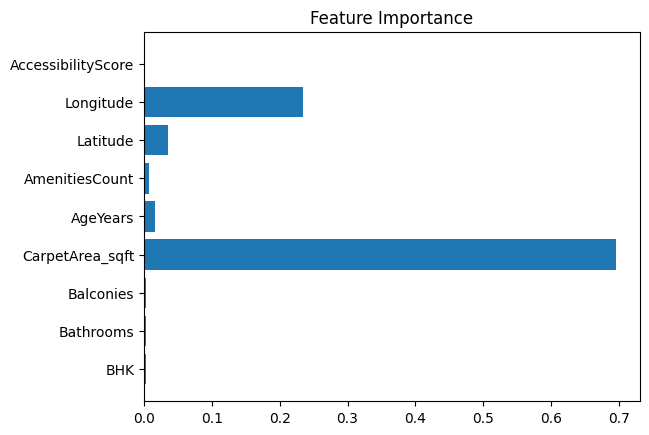

In [18]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = important_features

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

Save Model

In [25]:
joblib.dump(model, r'C:\Users\Samya\projects\House Prediction and Recommendation\models\model.pkl')
joblib.dump(scaler, r'C:\Users\Samya\projects\House Prediction and Recommendation\models\scaler.pkl')
joblib.dump(important_features, r'C:\Users\Samya\projects\House Prediction and Recommendation\models\features.pkl')

['C:\\Users\\Samya\\projects\\House Prediction and Recommendation\\models\\features.pkl']